# Walidacja GHT – od pojedynczego symbolu do pełnego obrazu

**Dlaczego klasyfikacja nie działała?**

| Problem | Objaw | Naprawa |
|---------|-------|---------|
| Wzorce za małe (`augmentation` 6x7, `barline` 4x94 = 1 krawędź) | Score=1.0 wszędzie | Minimalna liczba krawędzi (`MIN_EDGE_PIXELS`) |
| Tylko relatywny próg (% maks.) | Każdy wzorzec ma swoje maks. niezależnie od jakości | Dodaj **absolutny** próg (min. surowych głosów) |
| Normalizacja przez krawędzie wzorca | Mały wzorzec (10 krawędzi) -> score=1 przy 10 głosach | Surowe głosy + abs_min_votes |

**Plan:** (1) waliduj GHT na jednym wzorcu, (2) zanalizuj histogram akumulatora, (3) ustal dobre progi, (4) ranking wszystkich wzorców.

## 1. Importy i konfiguracja

In [17]:
import numpy as np
import cv2
import os
import time
import matplotlib.pyplot as plt
from collections import defaultdict

IMAGE_PATH   = 'notes.png'
PATTERNS_DIR = 'patterns'
SCALE        = 2
NUM_BINS     = 32
CANNY_LOW, CANNY_HIGH = 30, 100
MIN_EDGE_PIXELS = 30   # wzorce z mniejsza liczba krawedzi sa pomijane

def show(*pairs, h=5):
    n = len(pairs)//2
    fig, axes = plt.subplots(1, n, figsize=(min(7*n,22), h))
    if n==1: axes=[axes]
    for ax,img,title in zip(axes, pairs[::2], pairs[1::2]):
        kw = dict(cmap='gray',vmin=0,vmax=255) if img.ndim==2 else {}
        ax.imshow(img,**kw); ax.set_title(title,fontsize=9); ax.axis('off')
    plt.tight_layout(); plt.show()

print('OK')

OK


## 2. Preprocessing obrazu

Obraz: 2173x775 px  (skalowany 2x)


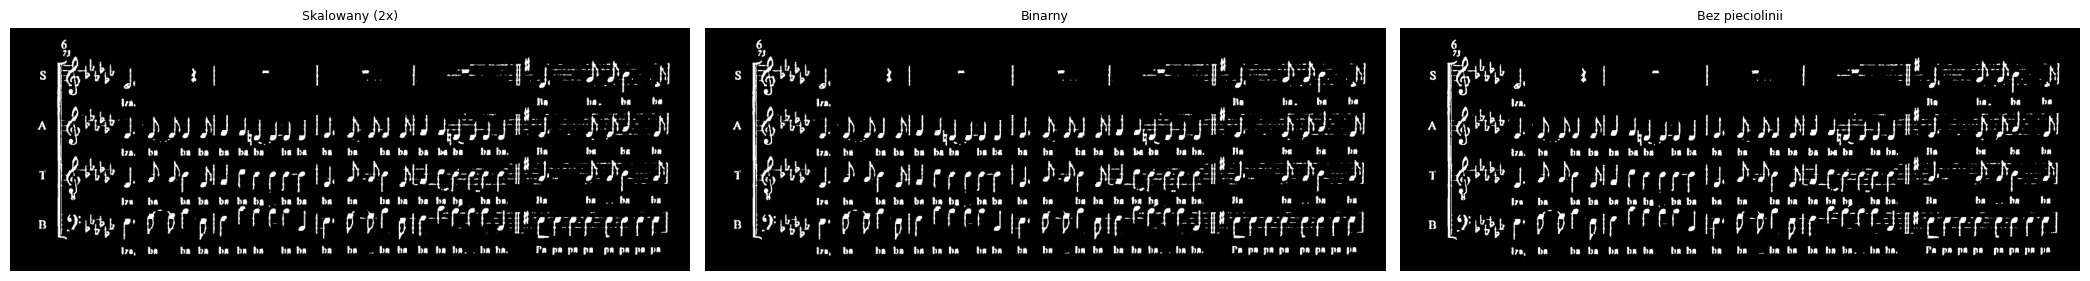

In [18]:
def preprocess(path, scale=SCALE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: raise FileNotFoundError(path)
    if scale!=1:
        img = cv2.resize(img, None, fx=scale, fy=scale, interpolation=cv2.INTER_CUBIC)
    if len(np.unique(img)) <= 2:
        _, b = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
        if b.mean() > 127: b = cv2.bitwise_not(b)
    else:
        _, b = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    return img, b

def remove_staff_lines(binary, ratio=0.30, scale=SCALE):
    H, W = binary.shape
    min_run = max(5, int(W*ratio))
    mask = np.zeros_like(binary)
    for y in range(H):
        row = binary[y]
        p = np.concatenate([[0], row.astype(np.int16), [0]])
        s = np.where((p[:-1]==0)&(p[1:]==255))[0]
        e = np.where((p[:-1]==255)&(p[1:]==0))[0]
        for si,ei in zip(s,e):
            if ei-si>=min_run: mask[y,si:ei]=255
    no_lines = cv2.subtract(binary, mask)
    k = cv2.getStructuringElement(cv2.MORPH_RECT,(1,max(5,3*scale)))
    return cv2.morphologyEx(no_lines, cv2.MORPH_CLOSE, k)

# img_gray, binary_raw = preprocess(IMAGE_PATH)
# binary_clean = remove_staff_lines(binary_raw)
binary_clean = cv2.imread(IMAGE_PATH, cv2.IMREAD_GRAYSCALE)
img_gray = cv2.resize(binary_clean, None, fx=1/SCALE, fy=1/SCALE, interpolation=cv2.INTER_AREA)
binary_raw = img_gray.copy()
H, W = binary_clean.shape
print(f'Obraz: {W}x{H} px  (skalowany {SCALE}x)')
show(img_gray, f'Skalowany ({SCALE}x)', binary_raw, 'Binarny', binary_clean, 'Bez pieciolinii')

## 3. Diagnostyka wzorcow -- ktore nadaja sie do GHT?

Wzorce z za mala liczba krawedzi daja falszywe detekcje wszedie.
Ustalamy minimalny prog absolutny: **>= MIN_EDGE_PIXELS** po skalowaniu.

In [19]:
def load_pattern(path, scale=SCALE):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    _, b = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)
    if scale!=1:
        b = cv2.resize(b, None, fx=scale, fy=scale, interpolation=cv2.INTER_NEAREST)
        _, b = cv2.threshold(b, 127, 255, cv2.THRESH_BINARY)
    return b

fnames = sorted(f for f in os.listdir(PATTERNS_DIR) if f.endswith('.png'))
good, bad = [], []
print(f"{'Wzorzec':<22} {'WxH':>10} {'Krawedzie':>10} {'Status':>8}")
print('-'*55)
for f in fnames:
    pat = load_pattern(os.path.join(PATTERNS_DIR,f), scale=SCALE)
    if pat is None: continue
    e = cv2.Canny(pat, CANNY_LOW, CANNY_HIGH)
    n = int((e>0).sum())
    name = f[:-4]
    status = 'OK' if n>=MIN_EDGE_PIXELS else 'POMIN'
    print(f"{f:<22} {pat.shape[1]:>4}x{pat.shape[0]:<4} {n:>10}  {status:>6}")
    (good if n>=MIN_EDGE_PIXELS else bad).append(name)
print(f'\nOK: {len(good)}  |  Pominieto: {len(bad)}  {bad}')

Wzorzec                       WxH  Krawedzie   Status
-------------------------------------------------------
12_8.png                 88x122         711      OK
2_2.png                  50x122         505      OK
3_2.png                  50x122         522      OK
3_4.png                  52x122         506      OK
3_8.png                  48x122         510      OK
4_4.png                  52x122         468      OK
5_4.png                  52x120         483      OK
5_8.png                  48x120         498      OK
6_4.png                  52x122         480      OK
6_8.png                  48x122         487      OK
7_8.png                  48x122         414      OK
9_8.png                  48x122         489      OK
augmentation.png         12x14           20   POMIN
barline.png               8x188           3   POMIN
barline_double.png       18x122         248      OK
barline_end.png          28x122         250      OK
barline_repeat.png       44x122         424      OK
bemol.

## 4. GHT na jednym wzorcu -- weryfikacja dzialania

Testuj jeden wzorzec i ogladaj akumulator.
Dobry wynik: wyrazne szczyty dokladnie w miejscach gdzie symbol wystepuje.

Wzorzec: note8  |  68x122 px  |  krawedzie: 377
Akumulator: max=94  mean=1.52


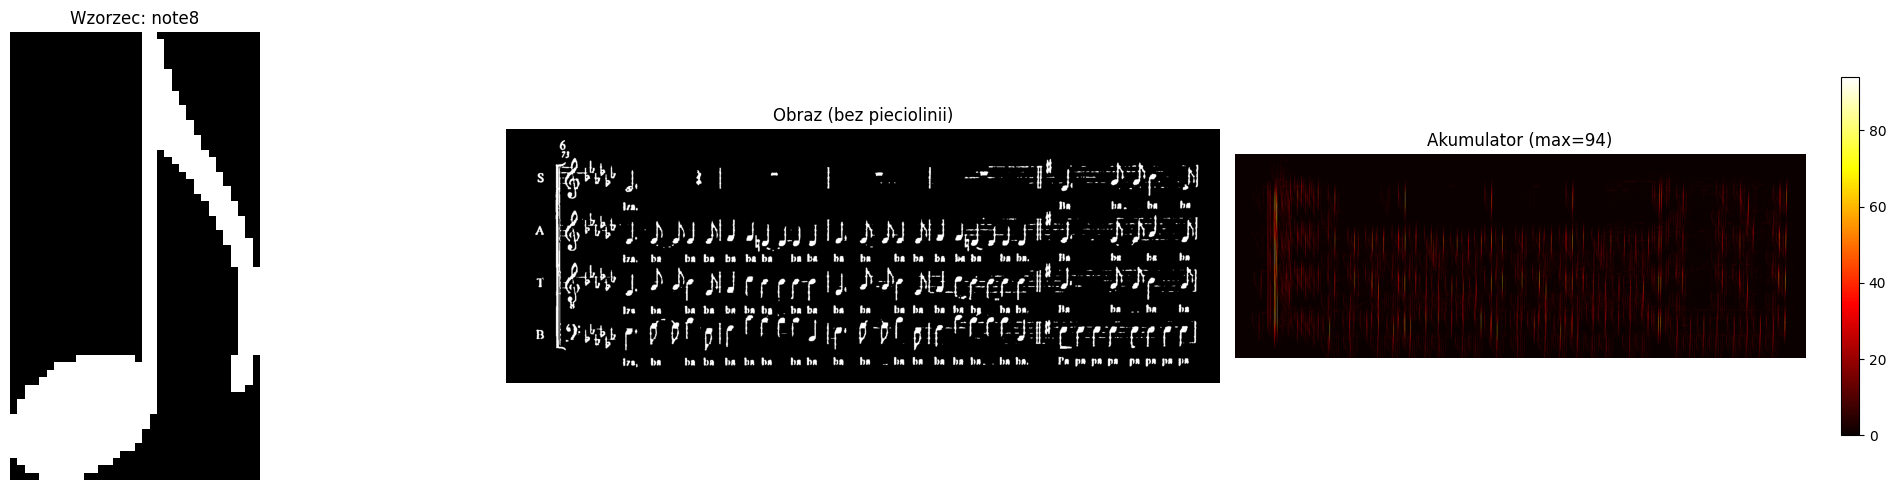

In [20]:
def build_r_table(pattern):
    ys, xs = np.where(pattern>0)
    if len(ys)==0: return None,None,0
    ref = (int(ys.mean()), int(xs.mean()))
    edges = cv2.Canny(pattern, CANNY_LOW, CANNY_HIGH)
    gx = cv2.Sobel(pattern, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(pattern, cv2.CV_64F, 0, 1, ksize=3)
    rt = defaultdict(list)
    pts = np.argwhere(edges>0)
    for (ey,ex) in pts:
        angle = np.degrees(np.arctan2(gy[ey,ex],gx[ey,ex]))%360
        b = int(angle/360*NUM_BINS)%NUM_BINS
        rt[b].append((ref[0]-ey, ref[1]-ex))
    return rt, ref, len(pts)

def ght_vote(binary, r_table):
    H,W = binary.shape
    accum = np.zeros((H,W), dtype=np.float32)
    edges = cv2.Canny(binary, CANNY_LOW, CANNY_HIGH)
    gx = cv2.Sobel(binary, cv2.CV_64F, 1, 0, ksize=3)
    gy = cv2.Sobel(binary, cv2.CV_64F, 0, 1, ksize=3)
    yx = np.argwhere(edges>0).astype(np.int32)
    if len(yx)==0: return accum
    angles = np.degrees(np.arctan2(gy[yx[:,0],yx[:,1]], gx[yx[:,0],yx[:,1]]))%360
    bins = (angles/360*NUM_BINS).astype(np.int32)%NUM_BINS
    for b_idx,vecs in r_table.items():
        sel = yx[bins==b_idx]
        if len(sel)==0 or len(vecs)==0: continue
        vecs = np.array(vecs, dtype=np.int32)
        vy = (sel[:,0:1]+vecs[np.newaxis,:,0]).ravel()
        vx = (sel[:,1:2]+vecs[np.newaxis,:,1]).ravel()
        valid = (vy>=0)&(vy<H)&(vx>=0)&(vx<W)
        np.add.at(accum,(vy[valid],vx[valid]),1)
    return accum

# --- TEST: zmien na dowolny wzorzec z folderu patterns/ ---
TEST_PATTERN = 'note8'

pat  = load_pattern(f'{PATTERNS_DIR}/{TEST_PATTERN}.png')
rt, ref, n_pat = build_r_table(pat)
print(f'Wzorzec: {TEST_PATTERN}  |  {pat.shape[1]}x{pat.shape[0]} px  |  krawedzie: {n_pat}')

accum_raw = ght_vote(binary_clean, rt)
print(f'Akumulator: max={accum_raw.max():.0f}  mean={accum_raw.mean():.2f}')

fig, axes = plt.subplots(1,3,figsize=(22,5))
axes[0].imshow(pat,cmap='gray'); axes[0].set_title(f'Wzorzec: {TEST_PATTERN}'); axes[0].axis('off')
axes[1].imshow(binary_clean,cmap='gray'); axes[1].set_title('Obraz (bez pieciolinii)'); axes[1].axis('off')
im=axes[2].imshow(accum_raw,cmap='hot'); axes[2].set_title(f'Akumulator (max={accum_raw.max():.0f})'); axes[2].axis('off')
plt.colorbar(im,ax=axes[2],shrink=0.8)
plt.tight_layout(); plt.show()

## 5. Poprawiony prog -- absolutny + relatywny

**Stara normalizacja:** `score = glosy / n_krawedzi_wzorca`  
Problem: male wzorce (10 krawedzi) osiagaja score=1 przy 10 glosach.

**Poprawka:** progi SUROWYCH glosow:
- `abs_min_votes` = min. 40% krawedzi wzorca, ale co najmniej 25
- `rel_thresh` = szczyt >= rel_thresh x globalnego maks.

In [29]:
def nms_peaks(accum, rel_thresh=0.35, abs_min_votes=25, nms_radius=20):
    """
    NMS z dwoma warunkami: relatywnym (procent maks.) i absolutnym (min. glosy).
    Efektywny prog = max(rel_thresh*maks, abs_min_votes).
    """
    if accum.max()<=0: return []
    thresh = max(rel_thresh*accum.max(), abs_min_votes)
    r = max(3,nms_radius)
    k = cv2.getStructuringElement(cv2.MORPH_ELLIPSE,(2*r+1,2*r+1))
    local_max = cv2.dilate(accum,k)
    mask = (accum==local_max)&(accum>=thresh)
    pts = np.argwhere(mask)
    return sorted([(int(y),int(x),float(accum[y,x])) for y,x in pts],key=lambda p:-p[2])

REL_THRESH    = 0.40
ABS_MIN_VOTES = max(25, int(0.10*n_pat))
NMS_RADIUS    = max(5, int(0.4*max(pat.shape)))

print(f'Progi: rel={REL_THRESH}  abs_min={ABS_MIN_VOTES}  nms_r={NMS_RADIUS}')
print(f'Efektywny prog: max({REL_THRESH}x{accum_raw.max():.0f}, {ABS_MIN_VOTES}) = {max(REL_THRESH*accum_raw.max(),ABS_MIN_VOTES):.1f}')

peaks = nms_peaks(accum_raw, REL_THRESH, ABS_MIN_VOTES, NMS_RADIUS)
print(f'\nWykryto szczytow: {len(peaks)}')
for i,(y,x,s) in enumerate(peaks[:15]):
    print(f'  #{i+1:2d}  y={y:4d}  x={x:5d}  glosy={s:.0f}')

Progi: rel=0.4  abs_min=37  nms_r=48
Efektywny prog: max(0.4x94, 37) = 37.6

Wykryto szczytow: 185
  # 1  y= 581  x=  160  glosy=94
  # 2  y= 375  x=  149  glosy=93
  # 3  y= 378  x=  149  glosy=93
  # 4  y= 395  x=  149  glosy=93
  # 5  y= 396  x=  149  glosy=93
  # 6  y= 201  x=  159  glosy=90
  # 7  y= 165  x=  647  glosy=86
  # 8  y= 166  x=  647  glosy=86
  # 9  y= 167  x=  647  glosy=86
  #10  y= 168  x=  647  glosy=86
  #11  y= 169  x=  647  glosy=86
  #12  y= 170  x=  647  glosy=86
  #13  y= 171  x=  647  glosy=86
  #14  y= 620  x=  936  glosy=84
  #15  y= 621  x=  936  glosy=84


## 6. Wizualizacja detekcji dla jednego wzorca

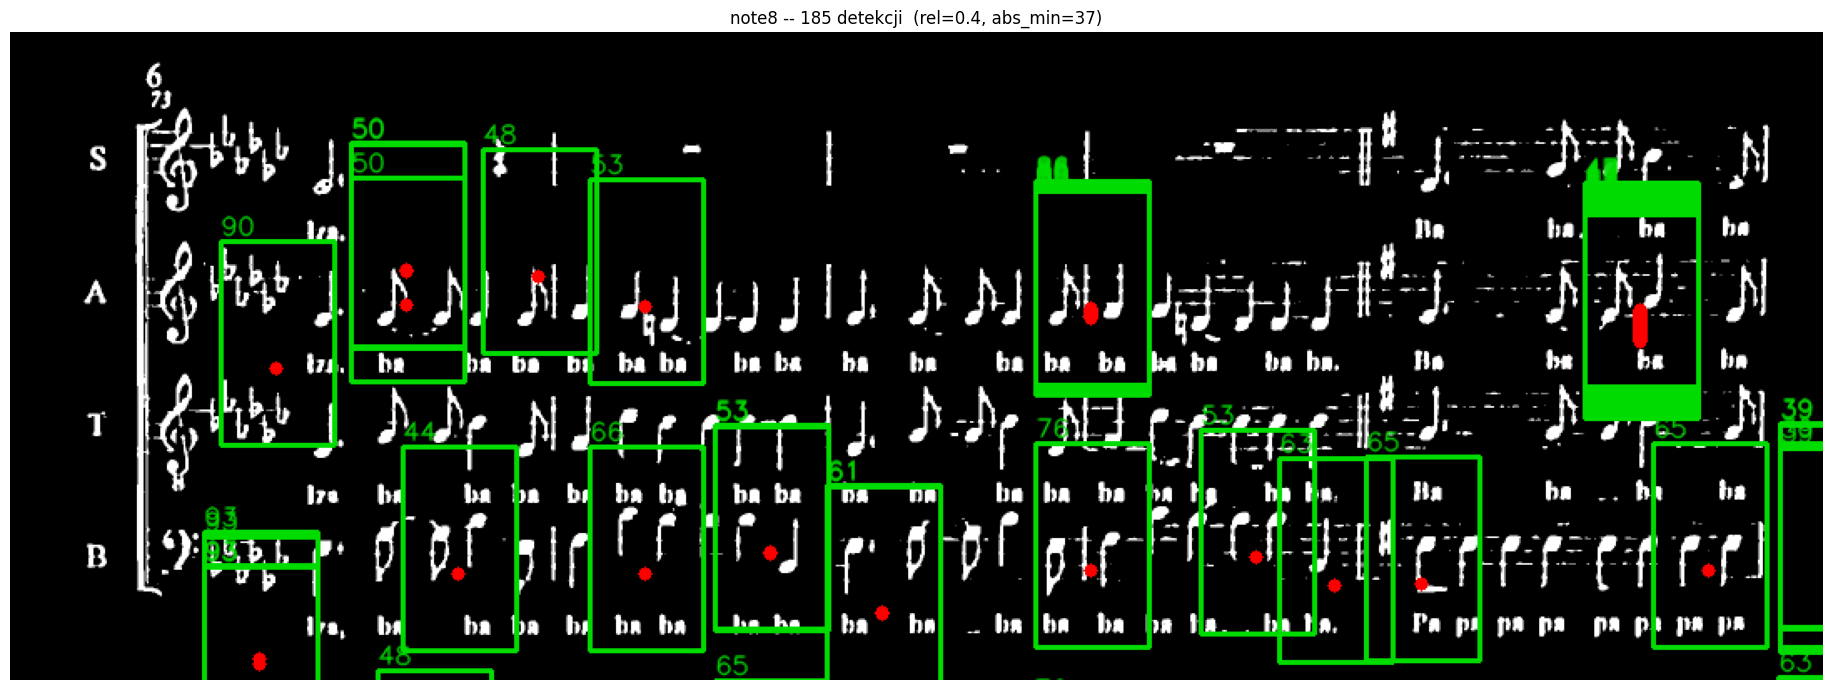

In [30]:
def draw_detections(img_gray, peaks, pat_shape, ref_point, color=(0,220,0)):
    vis = cv2.cvtColor(img_gray, cv2.COLOR_GRAY2BGR)
    hp,wp = pat_shape
    ry,rx = ref_point
    for rank,(cy,cx,score) in enumerate(peaks):
        x1,y1 = cx-rx, cy-ry
        cv2.rectangle(vis,(x1,y1),(x1+wp,y1+hp),color,2)
        cv2.circle(vis,(cx,cy),4,(0,0,255),-1)
        cv2.putText(vis,f'{score:.0f}',(x1,max(y1-4,12)),
                    cv2.FONT_HERSHEY_SIMPLEX,0.5,color,1,cv2.LINE_AA)
    return vis

result = draw_detections(img_gray, peaks, pat.shape, ref)
plt.figure(figsize=(22,7))
plt.imshow(cv2.cvtColor(result,cv2.COLOR_BGR2RGB))
plt.title(f'{TEST_PATTERN} -- {len(peaks)} detekcji  (rel={REL_THRESH}, abs_min={ABS_MIN_VOTES})',fontsize=12)
plt.axis('off'); plt.tight_layout(); plt.show()

## 7. Analiza progu -- krzywa detekcji vs. abs_min_votes

Szukamy miejsca gdzie liczba detekcji spada gwaltownie -- to granica szumu.

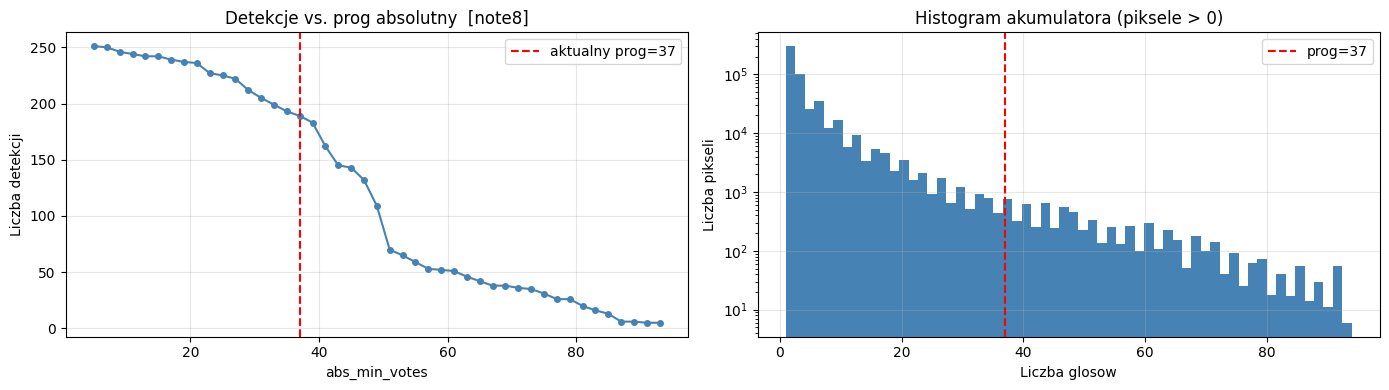

Max glosow: 94  |  40% max = 38


In [31]:
vote_range = range(5, int(accum_raw.max())+1, max(1,int(accum_raw.max()//40)))
counts = [len(nms_peaks(accum_raw, rel_thresh=0.0, abs_min_votes=v, nms_radius=NMS_RADIUS))
          for v in vote_range]

fig, axes = plt.subplots(1,2,figsize=(14,4))
axes[0].plot(list(vote_range),counts,'o-',ms=4,color='steelblue')
axes[0].axvline(ABS_MIN_VOTES,color='red',ls='--',label=f'aktualny prog={ABS_MIN_VOTES}')
axes[0].set_xlabel('abs_min_votes'); axes[0].set_ylabel('Liczba detekcji')
axes[0].set_title(f'Detekcje vs. prog absolutny  [{TEST_PATTERN}]')
axes[0].legend(); axes[0].grid(alpha=0.3)

nonzero = accum_raw[accum_raw>0].ravel()
axes[1].hist(nonzero, bins=60, color='steelblue', edgecolor='none')
axes[1].axvline(ABS_MIN_VOTES,color='red',ls='--',label=f'prog={ABS_MIN_VOTES}')
axes[1].set_xlabel('Liczba glosow'); axes[1].set_ylabel('Liczba pikseli')
axes[1].set_title('Histogram akumulatora (piksele > 0)'); axes[1].set_yscale('log')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()
print(f'Max glosow: {accum_raw.max():.0f}  |  40% max = {0.4*accum_raw.max():.0f}')

## 8. Ranking wszystkich wzorcow wg jakosci dopasowania

Dla kazdego wzorca: max akumulatora i liczba detekcji z poprawnymi progami.

In [32]:
results_summary = []
print(f"{'Wzorzec':<22} {'Kraw':>6} {'MaxGl':>7} {'AbsMin':>7} {'Det':>5} {'Ratio':>7}")
print('-'*58)

for fname in sorted(os.listdir(PATTERNS_DIR)):
    if not fname.endswith('.png'): continue
    name = fname[:-4]
    pat_i = load_pattern(os.path.join(PATTERNS_DIR,fname))
    rt_i, ref_i, n_i = build_r_table(pat_i)
    if n_i < MIN_EDGE_PIXELS:
        print(f'{fname:<22} {n_i:>6}  -- POMIN (za malo krawedzi)')
        results_summary.append(dict(name=name,n_edges=n_i,max_votes=0,detections=0,skip=True))
        continue
    acc_i = ght_vote(binary_clean, rt_i)
    abs_m = max(25, int(0.35*n_i))
    nms_r = max(5, int(0.4*max(pat_i.shape)))
    pk_i  = nms_peaks(acc_i, 0.35, abs_m, nms_r)
    ratio = acc_i.max()/n_i if n_i else 0
    flag  = '  <<< DOBRY' if ratio>0.45 and len(pk_i)>0 else ''
    print(f'{fname:<22} {n_i:>6} {acc_i.max():>7.0f} {abs_m:>7} {len(pk_i):>5} {ratio:>7.2f}{flag}')
    results_summary.append(dict(name=name,n_edges=n_i,max_votes=float(acc_i.max()),
                                 detections=len(pk_i),abs_min=abs_m,skip=False,ratio=ratio))

Wzorzec                  Kraw   MaxGl  AbsMin   Det   Ratio
----------------------------------------------------------
12_8.png                  711      84     248     0    0.12
2_2.png                   505      26     176     0    0.05
3_2.png                   522      37     182     0    0.07
3_4.png                   506      45     177     0    0.09
3_8.png                   510      28     178     0    0.05
4_4.png                   468      69     163     0    0.15
5_4.png                   483      52     169     0    0.11
5_8.png                   498      43     174     0    0.09
6_4.png                   480      46     168     0    0.10
6_8.png                   487      34     170     0    0.07
7_8.png                   414      29     144     0    0.07
9_8.png                   489      31     171     0    0.06
augmentation.png           20  -- POMIN (za malo krawedzi)
barline.png                 3  -- POMIN (za malo krawedzi)
barline_double.png        248     119      

## 9. Wizualizacja top-N wzorcow wg max glosow

Pokazuje wzorce: ['clef_alt', 'barline_end', 'barline_double', 'barline_repeat', 'note32', 'note2_']


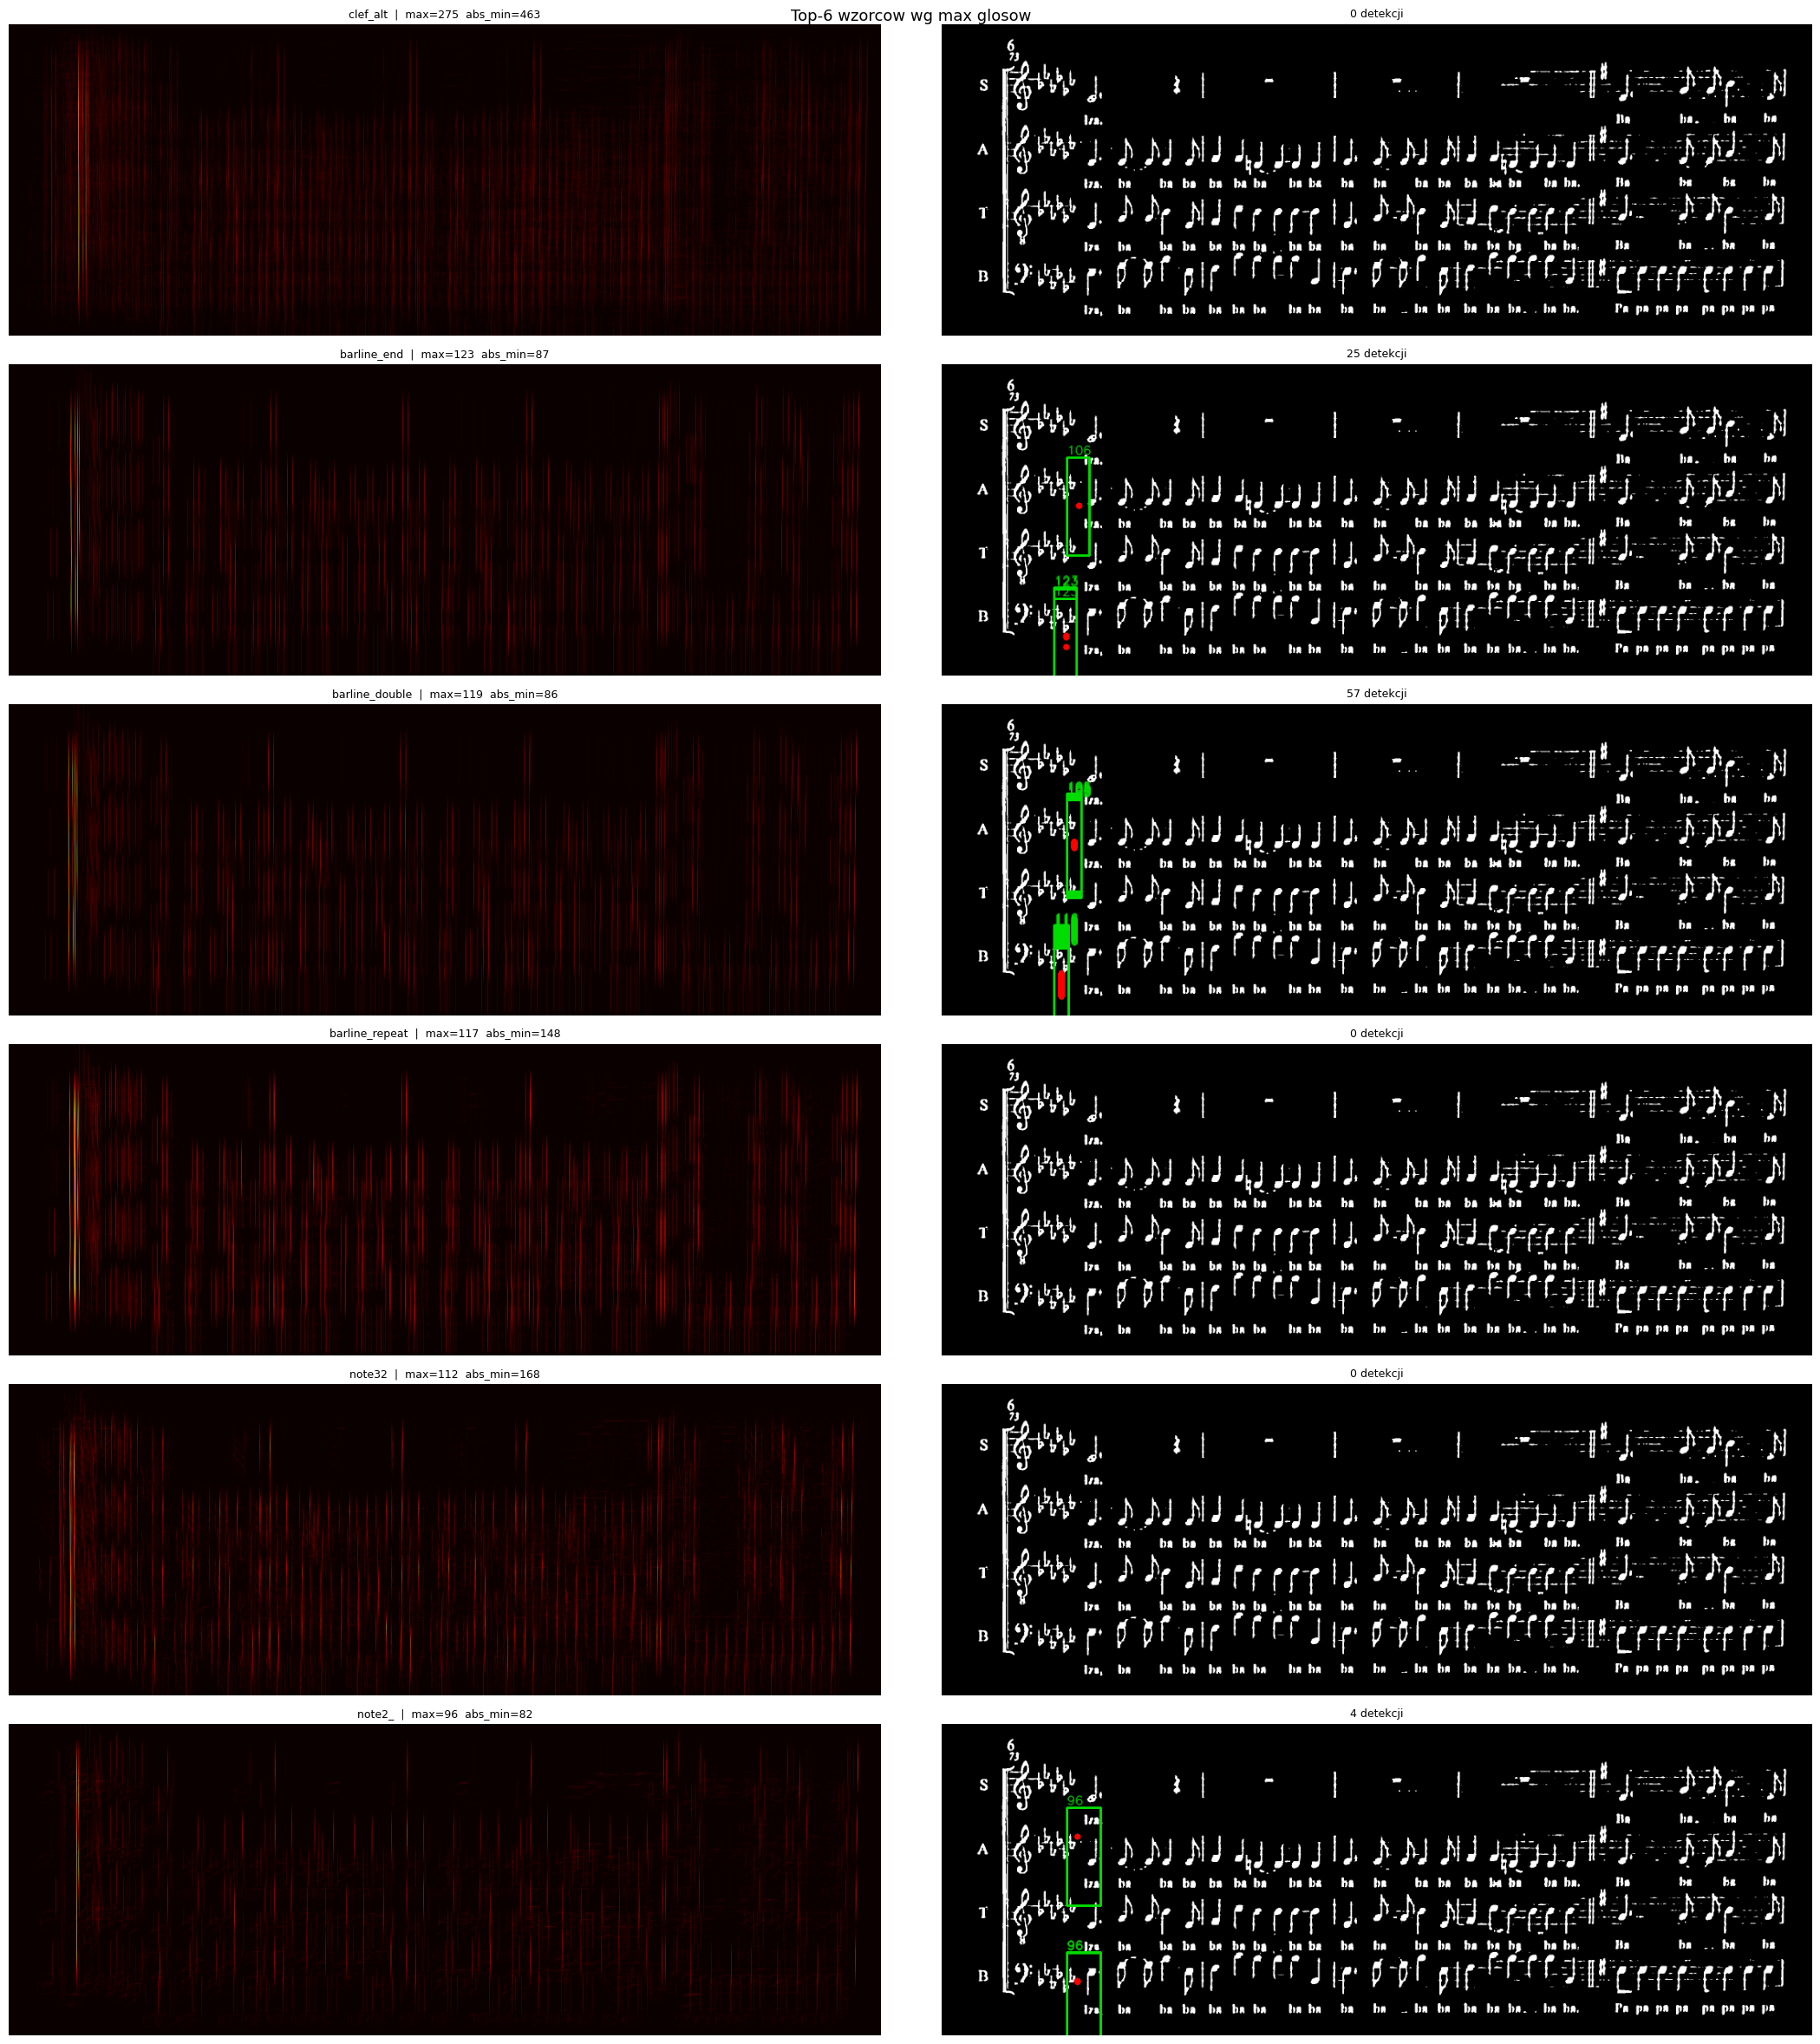

In [25]:
TOP_N = 6
ok = [r for r in results_summary if not r['skip']]
ok.sort(key=lambda r: -r['max_votes'])
top_names = [r['name'] for r in ok[:TOP_N]]
print('Pokazuje wzorce:', top_names)

fig, axes = plt.subplots(TOP_N, 2, figsize=(22, 4*TOP_N))
for i,name in enumerate(top_names):
    pat_i = load_pattern(f'{PATTERNS_DIR}/{name}.png')
    rt_i,ref_i,n_i = build_r_table(pat_i)
    acc_i = ght_vote(binary_clean, rt_i)
    abs_m = max(25,int(0.35*n_i))
    nms_r = max(5,int(0.4*max(pat_i.shape)))
    pk_i  = nms_peaks(acc_i,0.35,abs_m,nms_r)
    vis_i = draw_detections(img_gray, pk_i, pat_i.shape, ref_i)
    axes[i,0].imshow(acc_i,cmap='hot')
    axes[i,0].set_title(f'{name}  |  max={acc_i.max():.0f}  abs_min={abs_m}',fontsize=9); axes[i,0].axis('off')
    axes[i,1].imshow(cv2.cvtColor(vis_i,cv2.COLOR_BGR2RGB))
    axes[i,1].set_title(f'{len(pk_i)} detekcji',fontsize=9); axes[i,1].axis('off')
plt.suptitle(f'Top-{TOP_N} wzorcow wg max glosow',fontsize=13)
plt.tight_layout(); plt.show()

---
## Wnioski i kolejne kroki

Po tej walidacji:
1. **Wyklucz** wzorce z niska liczba krawedzi lub absurdalnymi detekcjami
2. **Dobierz** abs_min_votes per-wzorzec na podstawie histogramu (sekcja 7)
3. **Zidentyfikuj** wzorce z dobrym sygnalem (ratio max_votes/n_edges > 0.45)
4. Wroc do `classification.ipynb` z poprawnymi parametrami